In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../../")
import utils.data_utils as utils
import re

In [2]:
hdf = pd.HDFStore('../../data/data_raw.h5', mode='r')
keys = hdf.keys()
keys

['/D/data_240624_ReCellML_A123_Cell01_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell03_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell05_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell06_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell07_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell08_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell09_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell11_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell12_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell14_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell15_charac_30C',
 '/D/data_240626_ReCellML_A123_Cell04_charac_30C',
 '/D/data_240626_ReCellML_A123_Cell10_charac_30C',
 '/D/data_240628_ReCellML_A123_Cell13_charac_30C',
 '/D/data_240709_ReCellML_A123_cell01_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell02_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell03_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell04_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell05_charac_45oC',
 '/D/data_240709_ReCellML_

In [3]:
with pd.option_context('display.max_rows', None):
    print(hdf.get('/D/data_240624_ReCellML_A123_Cell01_charac_30C').groupby("Segment Description")["Segment Description"].count())

Segment Description
Charge depleting cycle                               11457
Charge sustaining cycle                               1800
Equilibration cycle after charge rest                  180
Equilibration cycle after discharge rest               180
Equilibration cycle charge CC                         6694
Equilibration cycle charge CV                           53
Equilibration cycle discharge CC                      6599
Equilibration cycle discharge CV                        13
HPPC                                                 44999
HPPC charge 10 SOC C/3 charge                         6581
HPPC charge 1C pulses                                 6600
HPPC charge 2C pulses                                 6600
HPPC charge 2C rapid pulses                           1760
HPPC charge C/10 pulses                               6600
HPPC charge C/2 pulses                                6600
HPPC charge PsRP 1                                   13200
HPPC charge PsRP 2                  

In [4]:
df = hdf.get('/D/data_240624_ReCellML_A123_Cell01_charac_30C')
temp = ['Charge depleting cycle' in seg_desc for seg_desc in df['Segment Description']]
df_ = df[temp].copy()
df_

,"Total Time, S",Cycle,Loop Counter #1,Loop Counter #2,Loop Counter #3,Step,"Step Time, S","Current, A","Voltage, V","Power, W","Amp-Hours, AH","Watt-Hours, WH","Temperature A1, °C",Mode,Real Time,Data Acquisition Flag,Segment Description,"Segment Time, S",SOC
267939,370425.3,1,1,1,1,198,1.0,-0.03,3.416,-0.1,0.0,0.0,29.5,DCHG,6/29/2024 1:00:45 PM,S,Charge depleting cycle,0.0,1.000000
267940,370426.3,1,1,1,1,199,1.0,-0.03,3.416,-0.1,0.0,0.0,30.0,DCHG,6/29/2024 1:00:46 PM,S,Charge depleting cycle,1.0,0.999997
267941,370427.3,1,1,1,1,200,1.0,-0.03,3.416,-0.1,0.0,0.0,30.0,DCHG,6/29/2024 1:00:47 PM,S,Charge depleting cycle,2.0,0.999993
267942,370428.3,1,1,1,1,201,1.0,-0.03,3.416,-0.1,0.0,0.0,30.0,DCHG,6/29/2024 1:00:48 PM,S,Charge depleting cycle,3.0,0.999990
267943,370429.3,1,1,1,1,202,1.0,-0.03,3.416,-0.1,0.0,0.0,30.0,DCHG,6/29/2024 1:00:49 PM,S,Charge depleting cycle,4.0,0.999986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279391,381877.3,1,1,1,1,250,1.0,-2.26,2.827,-6.3,0.0,0.0,30.5,DCHG,6/29/2024 4:11:36 PM,S,Charge depleting cycle,11452.0,0.001086
279392,381878.3,1,1,1,1,251,1.0,-2.63,2.816,-7.4,0.0,0.0,30.5,DCHG,6/29/2024 4:11:37 PM,S,Charge depleting cycle,11453.0,0.000801
279393,381879.3,1,1,1,1,252,1.0,-2.27,2.814,-6.3,0.0,0.0,30.5,DCHG,6/29/2024 4:11:38 PM,S,Charge depleting cycle,11454.0,0.000516
279394,381880.3,1,1,1,1,253,1.0,-2.24,2.809,-6.2,0.0,0.0,30.0,DCHG,6/29/2024 4:11:39 PM,S,Charge depleting cycle,11455.0,0.000254


Text(0.5, 1.0, 'Charge Depleting Cycle p')

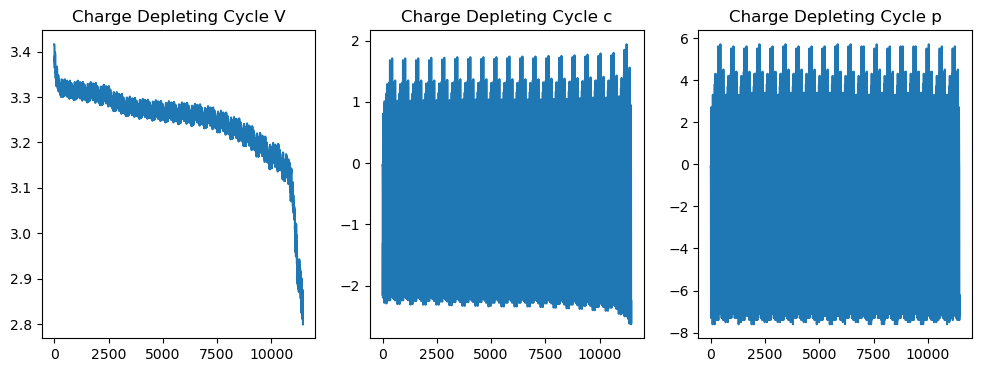

In [5]:
fig, ax = plt.subplots(ncols=3, figsize=(12,4))
time_data = df_['Total Time, S'] - df_['Total Time, S'][267939]
v_data = df_['Voltage, V']
c_data = df_['Current, A']
p_data = df_['Power, W']

ax[0].plot(time_data, v_data)
ax[0].set_title('Charge Depleting Cycle V')

ax[1].plot(time_data, c_data)
ax[1].set_title('Charge Depleting Cycle c')

ax[2].plot(time_data, p_data)
ax[2].set_title('Charge Depleting Cycle p')


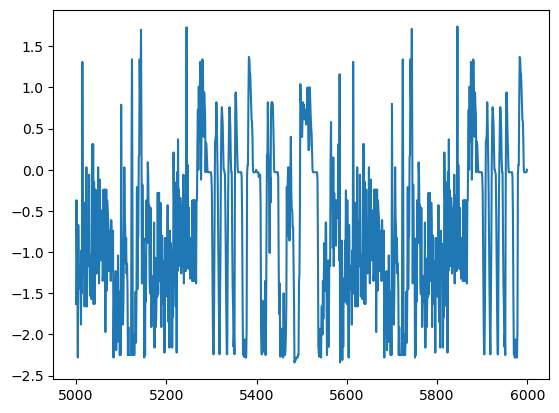

In [6]:
fig, ax = plt.subplots()
ax.plot(time_data[5000:6000], c_data[5000:6000])

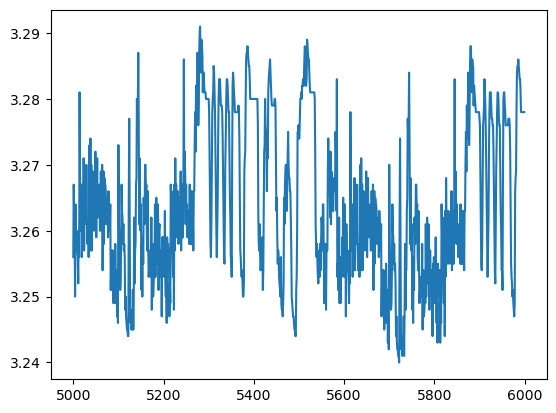

In [7]:
fig, ax = plt.subplots()
ax.plot(time_data[5000:6000], v_data[5000:6000])

In [8]:
hdf2 = pd.HDFStore('../../data/data_for_ml.h5', mode='r')
ml_keys = hdf2.keys()
ml_keys

['/DCIR',
 '/Dynamic_PsRP_1_1C',
 '/Dynamic_PsRP_2_1C',
 '/Static_HPPC',
 '/Static_PsRP_1',
 '/Static_PsRP_2_Chg',
 '/Static_PsRP_2_Dis',
 '/Static_Rapid',
 '/Dynamic_PsRP_2_C/2',
 '/Dynamic_PsRP_1_C/2']

In [9]:
# list(hdf2.get('/Dynamic_PsRP_1_1C').columns)
hdf2.get('/Dynamic_PsRP_1_1C')

,soc,direction,voltage_0.0s,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,voltage_5.0s,voltage_6.0s,voltage_7.0s,...,Charge depleting cycle charge throughput,Charge sustaining cycle charge efficiency,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE,Thickness growth,Volume growth
0,0.011132,charge,6.799,7.092,7.119,7.142,7.163,6.624,6.608,6.599,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
1,0.172361,charge,7.966,8.200,8.209,8.216,8.222,7.760,7.749,7.742,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
2,0.333591,charge,8.126,8.341,8.350,8.357,8.363,7.936,7.925,7.917,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
3,0.494596,charge,8.288,8.411,8.411,8.410,8.411,8.098,8.089,8.082,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
4,0.644375,charge,8.387,8.408,8.409,8.410,8.410,8.192,8.183,8.177,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4346,0.474158,discharge,3.195,3.289,3.298,3.305,3.310,3.253,3.251,3.251,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4347,0.387823,discharge,3.178,3.276,3.287,3.295,3.300,3.243,3.241,3.240,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4348,0.301488,discharge,3.151,3.253,3.267,3.276,3.282,3.225,3.222,3.221,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4349,0.215153,discharge,3.103,3.213,3.232,3.244,3.253,3.195,3.192,3.191,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN


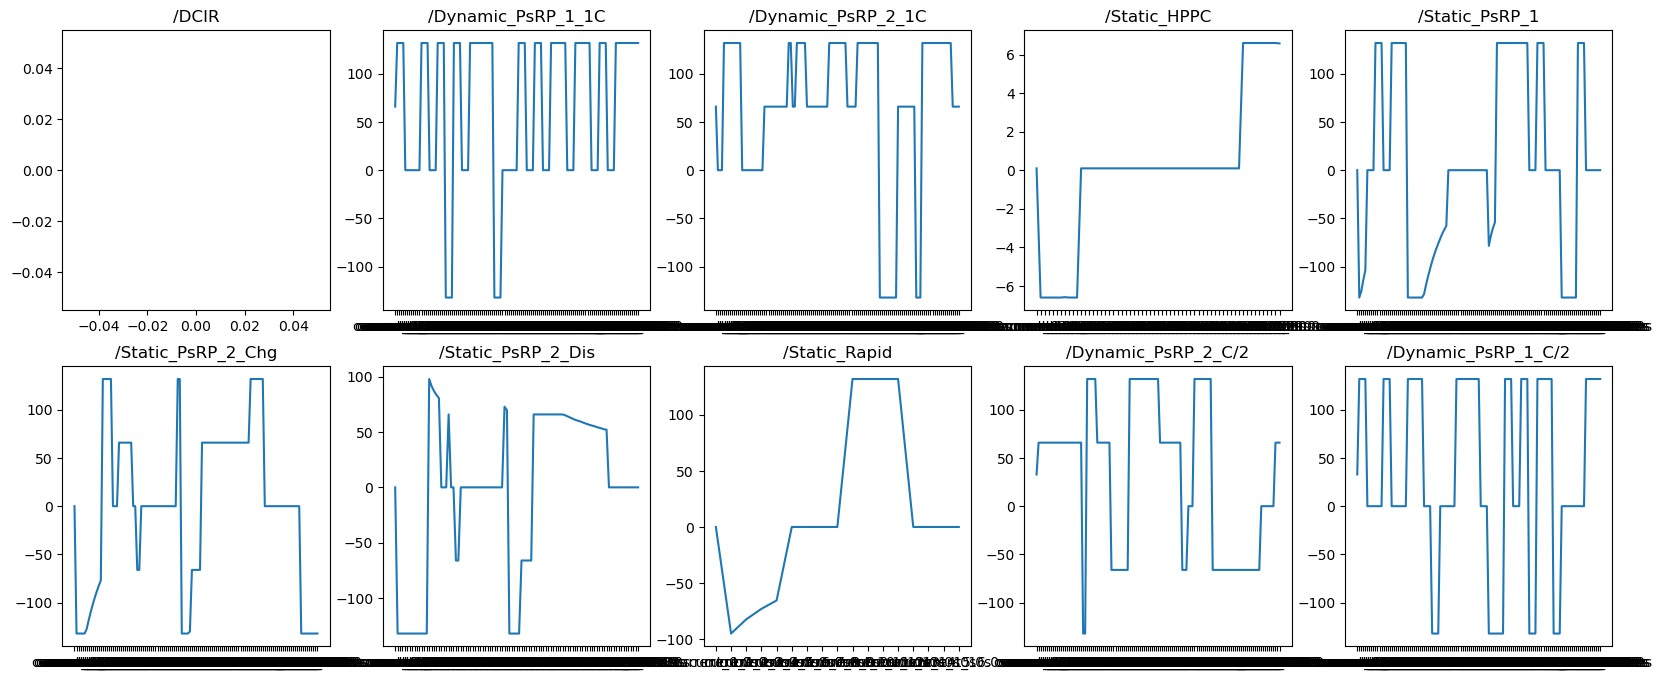

In [10]:
# with pd.option_context('display.max_rows', None):
fig, ax = plt.subplots(2,5, figsize=(20,8))
ax = ax.flatten()
for i, key in enumerate(ml_keys):
    #get voltage from one battery for each pulse type
    df = hdf2.get(key)
    # target = df.loc[df['cell_id'].str.contains('D')].loc[:, 'C/10 discharge capacity']
    target = df.iloc[0].filter(regex='current')
    ax[i].plot(target)
    ax[i].set_title(key)
# target

    
# ax.plot(target)

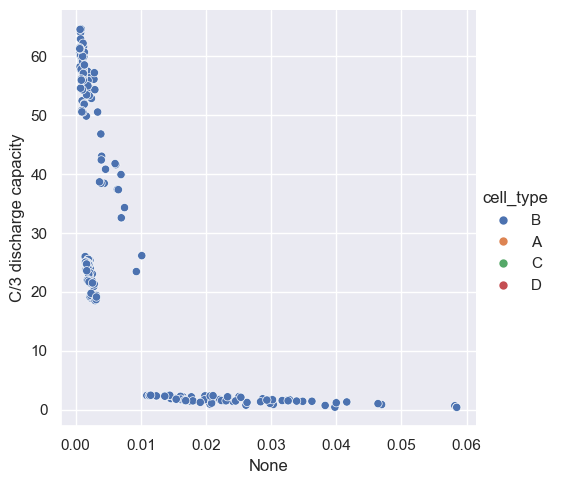

In [11]:
import seaborn as sns
sns.set_theme()

df['cell_type'] = [elem[0] for elem in df['cell_id']]
df_targets = pd.read_csv('../../data/targets_soh - manual volume and thickness edit.csv')
df_features = pd.read_csv('../../data/features_dcir.csv')
capacity = df_targets['C/3 discharge capacity']
# dcir is just the average of the charge and discharge resistance at 1C after 10s
dcir = (df_features['charge_resistance_10s_1C_charging'] + df_features['discharge_resistance_10s_1C_charging'])/2
# df = df.merge(df2, on='cell_id', how='inner')
# df = df.merge(df_features, on='cell_id', how='inner')
sns.relplot(x=dcir, y=capacity, data=df, hue='cell_type') #cell type not working?

In [12]:
list(df.columns)

['soc',
 'direction',
 'voltage_0.0s',
 'voltage_1.0s',
 'voltage_2.0s',
 'voltage_3.0s',
 'voltage_4.0s',
 'voltage_5.0s',
 'voltage_6.0s',
 'voltage_7.0s',
 'voltage_8.0s',
 'voltage_9.0s',
 'voltage_10.0s',
 'voltage_11.0s',
 'voltage_12.0s',
 'voltage_13.0s',
 'voltage_14.0s',
 'voltage_15.0s',
 'voltage_16.0s',
 'voltage_17.0s',
 'voltage_18.0s',
 'voltage_19.0s',
 'voltage_20.0s',
 'voltage_21.0s',
 'voltage_22.0s',
 'voltage_23.0s',
 'voltage_24.0s',
 'voltage_25.0s',
 'voltage_26.0s',
 'voltage_27.0s',
 'voltage_28.0s',
 'voltage_29.0s',
 'voltage_30.0s',
 'voltage_31.0s',
 'voltage_32.0s',
 'voltage_33.0s',
 'voltage_34.0s',
 'voltage_35.0s',
 'voltage_36.0s',
 'voltage_37.0s',
 'voltage_38.0s',
 'voltage_39.0s',
 'voltage_40.0s',
 'voltage_41.0s',
 'voltage_42.0s',
 'voltage_43.0s',
 'voltage_44.0s',
 'voltage_45.0s',
 'voltage_46.0s',
 'voltage_47.0s',
 'voltage_48.0s',
 'voltage_49.0s',
 'voltage_50.0s',
 'voltage_51.0s',
 'voltage_52.0s',
 'voltage_53.0s',
 'voltage_54.0s'

# PCA

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [14]:
#determine high, medium, and low capacity batteries
cell_types = ['A', 'B', 'C', 'D']
nominal_capacity = [65, 66, 26, 2.5]
categories = ['high', 'medium', 'low']

for type, cap in zip(cell_types, nominal_capacity):
    temp = df_targets.loc[df_targets['cell_id'].str.contains(type)]
    relative_capacity = temp['C/3 discharge capacity']/cap
    df_targets.loc[df_targets['cell_id'].str.contains(type), 'relative capacity'] = relative_capacity
    
    if type != 'B':
        df_targets.loc[(df_targets['cell_id'].str.contains(type)) & (relative_capacity > 0.9), 'capacity category'] = 'high'
        df_targets.loc[(df_targets['cell_id'].str.contains(type)) & (relative_capacity <= 0.9) & (relative_capacity > 0.8), 'capacity category'] = 'medium'
        df_targets.loc[(df_targets['cell_id'].str.contains(type)) & (relative_capacity <= 0.8), 'capacity category'] = 'low'
    else:
        df_targets.loc[(df_targets['cell_id'].str.contains(type)) & (relative_capacity > 0.8), 'capacity category'] = 'high'
        df_targets.loc[(df_targets['cell_id'].str.contains(type)) & (relative_capacity <= 0.8) & (relative_capacity > 0.7), 'capacity category'] = 'medium'
        df_targets.loc[(df_targets['cell_id'].str.contains(type)) & (relative_capacity <= 0.7), 'capacity category'] = 'low'



In [15]:
train_x = df_targets.drop(columns=['Unnamed: 0', 'Unnamed: 21', 'measurement_id', 'C/3 discharge capacity', 'relative capacity', 'capacity category', 'Thickness growth', 'Volume growth', 'Excess electrolyte'])
train_a = train_x.loc[train_x.cell_id.str.contains('A')].drop(columns=['cell_id'])
train_b = train_x.loc[train_x.cell_id.str.contains('B')].drop(columns=['cell_id'])
train_c = train_x.loc[train_x.cell_id.str.contains('C')].drop(columns=['cell_id'])
train_d = train_x.loc[train_x.cell_id.str.contains('D')].drop(columns=['cell_id'])

y_a = df_targets.loc[df_targets.cell_id.str.contains('A'), 'capacity category']
y_b = df_targets.loc[df_targets.cell_id.str.contains('B'), 'capacity category']
y_c = df_targets.loc[df_targets.cell_id.str.contains('C'), 'capacity category']
y_d = df_targets.loc[df_targets.cell_id.str.contains('D'), 'capacity category']

data = {
    'A': (train_a, y_a),
    'B': (train_b, y_b),
    'C': (train_c, y_c),
    'D': (train_d, y_d)
}
# data

In [16]:
#standardize features
scaler = StandardScaler()

results = {}

for i, (x, y) in enumerate(data.values()):
    x_scaled = scaler.fit_transform(x)
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(x_scaled)
    x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.3, random_state=42)
    # model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
    model = LogisticRegression()
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = np.mean(y_pred == y_test)
    print(f'Accuracy: {accuracy:.2f}')
    results[i] = (x_scaled, x_pca, x_train, x_test, y_train, y_test, y_pred)

Accuracy: 0.93
Accuracy: 1.00
Accuracy: 0.93
Accuracy: 0.96


In [17]:
# pca = PCA(n_components=2)
# x_pca = pca.fit_transform(a_scaled)
# results = []
# for i, (x, y) in enumerate(data):
#     x_scaled = scaler.fit_transform(x)
#     x_pca = pca.fit_transform(x_scaled)
#     results.append((x_pca, y))
# X_train, X_test, y_train, y_test = train_test_split(x_pca, y_a, test_size=0.3, random_state=42)


# model = LogisticRegression()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

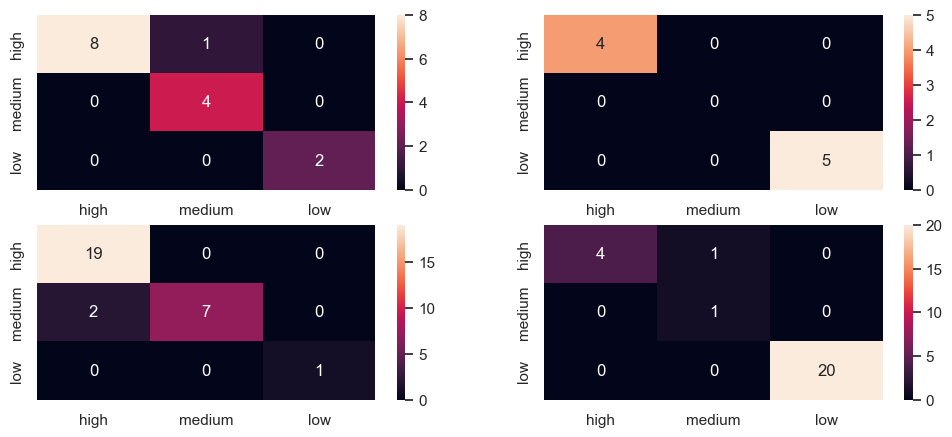

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(12, 5))
ax = ax.flatten()

for i, (x_scaled, x_pca, x_train, x_test, y_train, y_test, y_pred) in results.items():
    cm = confusion_matrix(y_test, y_pred, labels=categories)
    ax[i] = sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, ax=ax[i])


# plt.figure(figsize=(8,6))
# sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories)
# plt.xlabel('Predicted') 
# plt.ylabel('True')
# plt.title('Confusion Matrix for Capacity Classification (A cells only)')
# plt.show()

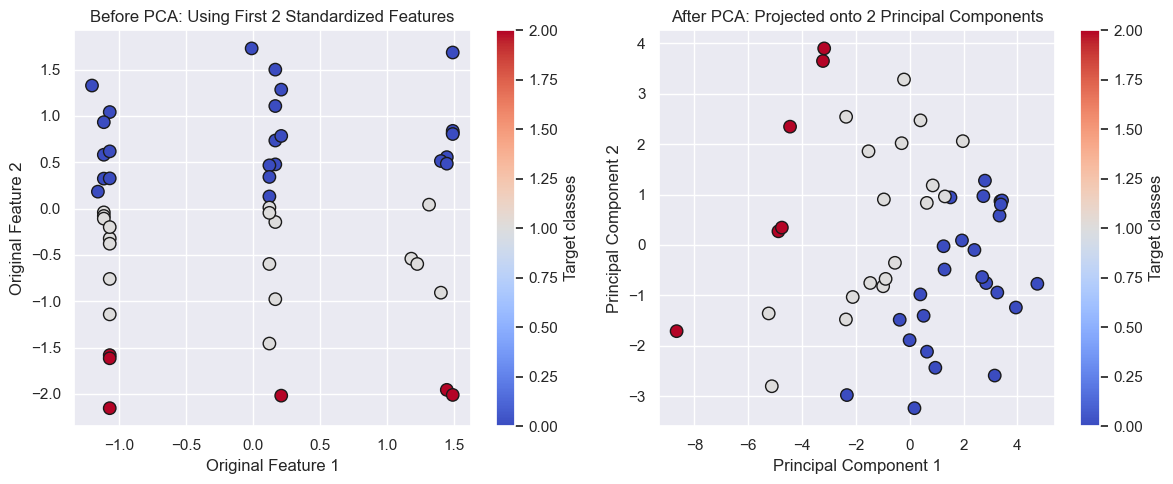

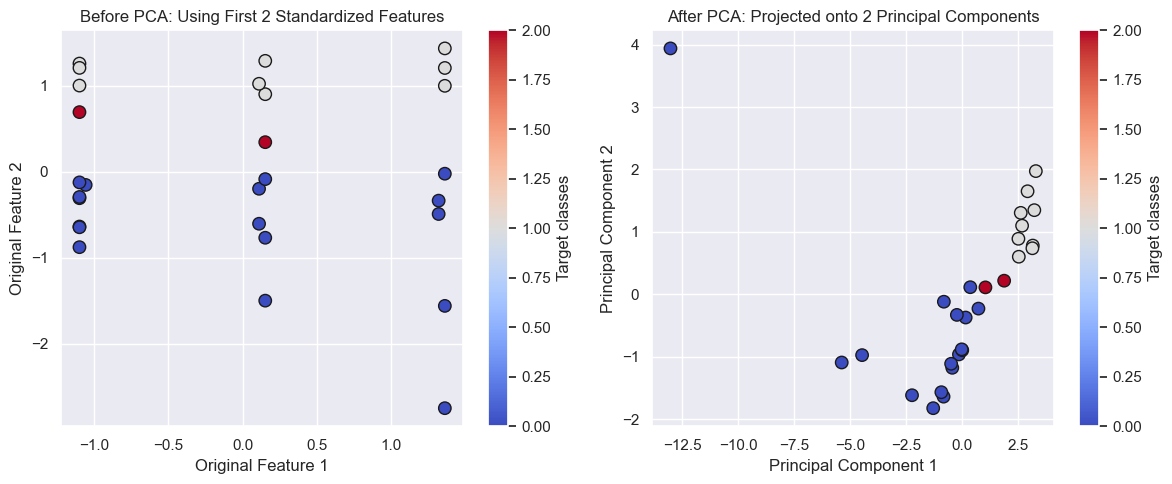

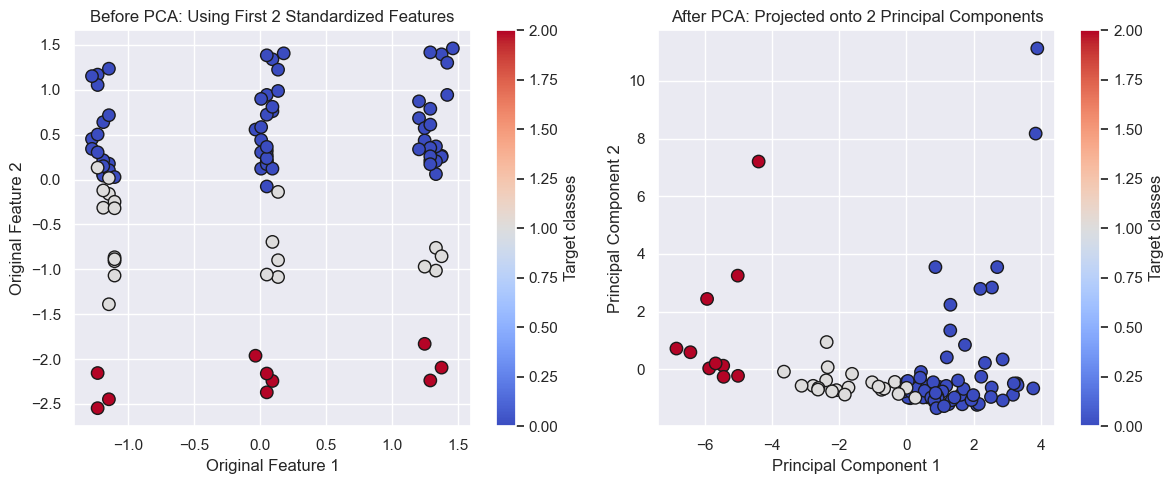

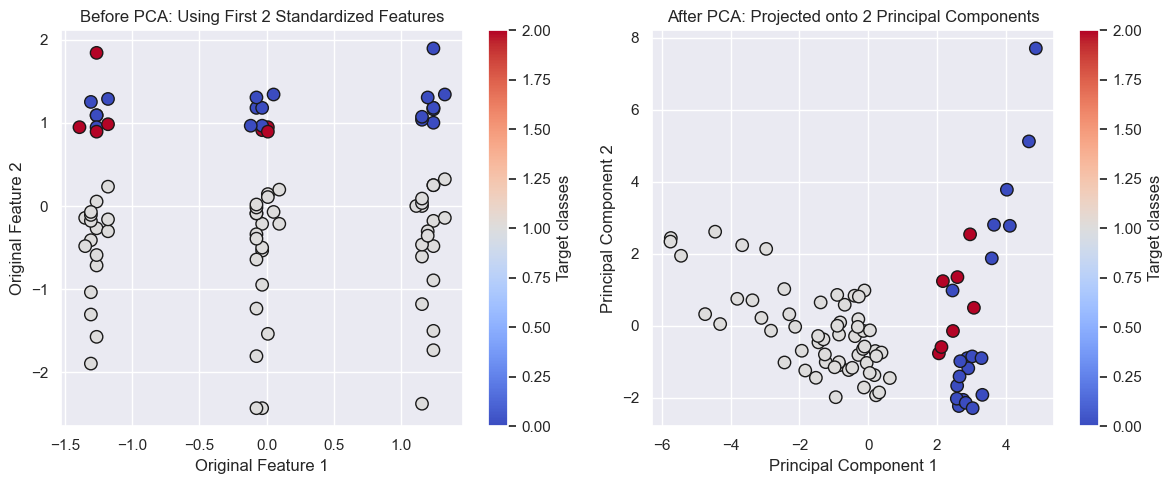

In [19]:


# fig, ax=plt.subplots(4,2, figsize=(12, 20))

for (i, (x_scaled, x_pca, x_train, x_test, y_train, y_test, y_pred)), (j, (train_x, y)) in zip(results.items(), data.items()):

    y_numeric = pd.factorize(y)[0]
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
    plt.xlabel('Original Feature 1')
    plt.ylabel('Original Feature 2')
    plt.title('Before PCA: Using First 2 Standardized Features')
    plt.colorbar(label='Target classes')

    plt.subplot(1, 2, 2)
    plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('After PCA: Projected onto 2 Principal Components')
    plt.colorbar(label='Target classes')

    plt.tight_layout()
    plt.show()

In [20]:
#determine high, medium, and low dcir batteries
# for type, cap in zip(cell_types, nominal_capacity):

data['A'][0]
    

,temperature_ambient,C/10 discharge capacity,C/5 discharge capacity,C/2 discharge capacity,1C discharge capacity,P/3 discharge capacity,Charge depleting cycle charge throughput,Charge sustaining cycle charge efficiency,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE
28,31.0,64.34,64.25,63.63,62.78,63.90,84.702030,1.288222,1.600000e-07,1.390000e-07,1.580000e-07,1.540000e-07,9.930000e-07,6.300000e-07
29,31.5,63.51,63.13,62.73,62.19,62.85,82.888174,1.292724,1.620000e-07,1.460000e-07,1.570000e-07,3.330000e-07,2.930000e-07,1.410000e-06
30,31.0,58.02,57.80,57.52,57.41,57.65,76.459474,1.288480,1.830000e-07,1.560000e-07,1.840000e-07,1.280000e-07,4.100000e-07,1.050000e-06
31,30.5,59.08,58.85,58.55,58.20,58.65,77.800213,1.287888,1.490000e-07,1.310000e-07,1.490000e-07,1.550000e-07,5.100000e-07,2.900000e-07
32,29.0,65.22,64.99,64.11,63.01,64.34,84.933812,1.286975,2.160000e-07,2.220000e-07,2.080000e-07,1.910000e-07,2.880000e-06,1.010000e-06
33,30.5,58.62,58.44,58.32,58.20,58.31,77.563875,1.289376,1.380000e-07,1.580000e-07,1.850000e-07,1.540000e-07,5.480000e-07,1.280000e-06
34,30.5,52.98,52.65,52.34,52.18,52.45,69.316921,1.288406,1.720000e-07,2.110000e-07,1.980000e-07,2.070000e-07,2.250000e-06,1.130000e-06
35,17.0,57.34,57.01,56.43,55.93,56.52,74.163008,1.282003,3.330000e-07,2.560000e-07,4.180000e-07,2.680000e-07,1.960000e-06,1.530000e-06
36,16.5,58.42,58.04,57.20,56.23,57.37,75.290367,1.281221,1.730000e-07,2.100000e-07,2.130000e-07,2.480000e-07,9.670000e-07,1.810000e-06
37,16.5,58.27,57.99,57.43,56.78,57.59,75.302429,1.283266,1.690000e-07,3.830000e-07,2.220000e-07,2.620000e-07,9.180000e-07,1.890000e-06


# DCIR extraction from Pulse Data

can definitely do it with static hppc, can it be done with others?

In [21]:
from scipy import integrate
from scipy.stats import norm
def generate_prbs(pulse_durations, pulse_currents, total_duration, rest=30, dc_bias=0., dc_bias_mode='constant', seed=12345):
    """
    Generates a sequence of pulses with random durations and random currents drawn from the input sets.
    The sequence is mirrored so the total change of SOC is 0 (charge sustaining). A DC bias can be added
    to the sequence to make the pulse charge depleting (during discharge) or charge accumulating.
    
    Inputs
    ----------
    pulse_durations [int]: pulse times to choose from, e.x., np.linspace(2, 10, 4) to get [2, 4, 6, 8, 10]
    pulse_currents [int]: pulse currents to choose from, e.x., np.linspace(-3, 3, 5) to get [-3, -1.5, 0, 1.5, 3]
    total_duration [int]: total duration of the PRBS in seconds (even value, or rounded up if it isn't)
    rest [int] (default=30): rest duration in seconds before and after pulse test
    dc_bias [float] (default=0): apply a DC bias to the sequence
    dc_bias_mode [string] (default='constant'): method for applying the bias
        'constant': simply adds a DC bias current to the randomly generated pulses
        'weighted_dist': use a weighted distribution to pick pulse currents that will converge towards the dc_bias
    seed [int] (default=12345): seed random number generator

    Outputs
    ----------
    Total_Time: time vector for the pulse sequence in seconds
    Step: step number during the pulse sequence
    Step_Time: time vector for each individual current step in seconds
    Current: current magnitude at each seconds

    """
    # Make total_duration even
    total_duration += total_duration % 2 
    rng = np.random.default_rng(seed)

    # Generate step times and currents
    step_times = rng.choice(pulse_durations, total_duration)
    
    if dc_bias_mode == 'weighted_dist':
        # Check that the DC bias is within the range of the pulse currents
        assert(np.logical_or(dc_bias < np.max(pulse_currents), dc_bias > np.min(pulse_currents)))
        mu = dc_bias
        sigma = (np.max(pulse_currents) - np.min(pulse_currents))/3
        p = norm.pdf(pulse_currents, loc=mu, scale=sigma)
        # Instatiate current sampler
        currents = rng.choice(pulse_currents, total_duration, p=p/np.sum(p))

        # Only keep steps up until the duration
        mask = np.cumsum(step_times) < total_duration

        # Add a one onto the end of the sequence to grab one more value
        _mask = np.empty_like(mask)
        _mask[:1] = True
        _mask[1:] = mask[:-1]
        mask = _mask
        step_times = step_times[mask]
        currents = currents[mask]
        stepnums = np.arange(step_times.size) + 1

        # Change last step time so accumulated time is equal to duration/2
        sum_time = np.sum(step_times[:-1])
        step_times[-1] = total_duration - sum_time
    else:
        # Instatiate current sampler
        currents = rng.choice(pulse_currents, total_duration)

        # Only keep steps until half the duration
        mask = np.cumsum(step_times) < total_duration/2

        # Add a one onto the end of the sequence to grab one more value
        _mask = np.empty_like(mask)
        _mask[:1] = True
        _mask[1:] = mask[:-1]
        mask = _mask
        step_times = step_times[mask]
        currents = currents[mask]
        stepnums = np.arange(step_times.size) + 1

        # Change last step time so accumulated time is equal to duration/2
        sum_time = np.sum(step_times[:-1])
        step_times[-1] = total_duration/2 - sum_time
        
        # Mirror step times, currents, and stepnums
        step_times = np.int32(np.hstack((step_times, np.flip(step_times))))
        currents = np.hstack((currents, -1*np.flip(currents)))
        stepnums = np.int32(np.hstack((stepnums, stepnums+np.max(stepnums))))

    # Generate time vector, instantiate other vectors
    Total_Time = np.arange(total_duration)
    Step = np.zeros(Total_Time.shape)
    Step_Time = np.zeros(Total_Time.shape)
    Current = np.zeros(Total_Time.shape)
    # step through time vector, filling in random currents of random duration
    t=0
    idx = 0
    while t < total_duration:
        this_step_time = step_times[idx]
        this_step_current = currents[idx]
        this_step = stepnums[idx]
        if t + this_step_time < total_duration:
            Step[t:(t+this_step_time)] = this_step
            Step_Time[t:(t+this_step_time)] = np.arange(this_step_time)
            Current[t:(t+this_step_time)] = this_step_current
        else:
            Step[t:] = this_step
            Step_Time[t:] = np.arange(total_duration - t)
            Current[t:] = this_step_current
        idx += 1
        t += this_step_time
    
    if dc_bias_mode == 'constant':
        # Apply constant DC bias
        Current += dc_bias
    
    # Pre/postpend rest
    if rest > 0:
        Total_Time = np.hstack((np.arange(rest*2), Total_Time+rest*2))
        Step_Time = np.hstack((np.arange(rest), Step_Time, np.arange(rest)))
        Step = np.hstack((np.full((rest,), 1), Step+1, np.full((rest,), Step[-1]+2)))
        Current = np.hstack((np.zeros((rest,)), Current, np.zeros((rest,))))

    return (Total_Time, Step, Step_Time, Current)

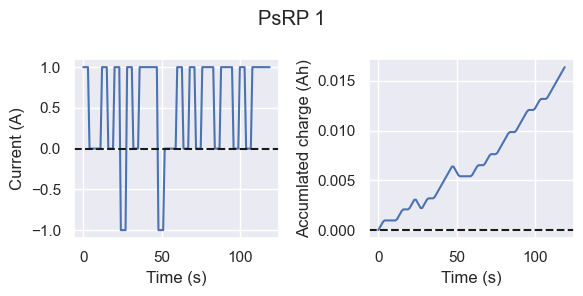

In [22]:
# PsRP_1 settings (weighted_dist 1 C bias):
max_c_rate = 2
dc_bias_c_rate = 1

total_duration = 2*60
# pulse durations
start = 4
stop = 4
steps = 1
pulse_durations = np.linspace(start, stop, num=steps, dtype=int)
# pulse current
start = -1
stop = 1
steps = 3
pulse_currents = np.linspace(start, stop, num=steps)
# random seed
seed = 77718860 # RESULT FROM WHILE LOOP BELOW, 2-28-2023 v1

# what should be the SOC change at 1/4 C bias?
target = ((1/max_c_rate) * dc_bias_c_rate) * (120/3600)
# run a while loop until we find a random seed within X% of this value
psrp_ah = 100000000000
while np.abs(target - psrp_ah) > (target * 0.02):
    # seed = np.random.randint(1, 1e8, 1)
    # Generate PRBS (default = charge sustaining)
    (Total_Time, Step, Step_Time, Current) = generate_prbs(pulse_durations, pulse_currents, total_duration, seed=seed, rest=0, dc_bias=1/3, dc_bias_mode='weighted_dist')
    ah = integrate.cumulative_trapezoid(Current, initial=0)/3600
    psrp_ah = ah[-1]

# Plot
fig, ax = plt.subplots(1, 2, figsize=(6,3))

ax[0].plot(Total_Time, Current)
ax[0].axhline(0, color='k', ls='--')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Current (A)')

ax[1].plot(Total_Time, integrate.cumulative_trapezoid(Current, initial=0)/3600)
ax[1].axhline(0, color='k', ls='--')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Accumlated charge (Ah)')

fig.suptitle('PsRP 1')
plt.tight_layout()

In [23]:
hdf = pd.HDFStore('../../data/data_for_ml.h5', mode='r')
df_pulse = hdf.get('/Dynamic_PsRP_1_1C')

mask_current = ['current' in col for col in df_pulse.columns]
mask_voltage = ['voltage' in col for col in df_pulse.columns]

currents = df_pulse.loc[:, mask_current].to_numpy()
voltages = df_pulse.loc[:, mask_voltage].to_numpy()
#attempts at getting resistance from psrp pulse data
pulse_profile = pd.read_csv('dynamic_PsRP_1_current_profile.csv',index_col=0)['0']
# pulse_profile
pulse_profile[pulse_profile < 0].index
currents_discharge = currents[pulse_profile[pulse_profile < 0].index]
currents_charge = currents[pulse_profile[pulse_profile > 0].index]
voltages_discharge = voltages[pulse_profile[pulse_profile < 0].index]
voltages_charge = voltages[pulse_profile[pulse_profile > 0].index]

# for i in range(4456):
#     plt.plot(range(121), currents[i], c=cmap(row.soc))

overpotentials_charge = voltages_charge - np.expand_dims(voltages_charge[:,0], 1)
instantaneous_resistances_charge = overpotentials_charge / currents_charge
resistances_charge = np.max(instantaneous_resistances_charge, 1)

overpotentials_discharge = voltages_discharge - np.expand_dims(voltages_discharge[:,0], 1)
instantaneous_resistances_discharge = overpotentials_discharge / currents_discharge
resistances_discharge = np.max(instantaneous_resistances_discharge, 1)

#This pulse has 8 seconds of discharge, and 68 of charge
# the resistance vectors are different lengths because of this
# not the case during static hppc pulse

resistance = np.mean(np.stack((resistances_discharge, resistances_charge)), 0)

df_pulse['resistance'] = resistance

ValueError: all input arrays must have the same shape